# Compare Ground-Truth vs ColabFold-Predicted Structures for the Hbond Mechanical-Property Predictor

This notebook evaluates whether the sequence -> predicted structure -> mechanical-property prediction path is reasonable on the **random test split** used by the structure-based hbond/topology random-forest predictor.

It compares two inputs for the same test entries:

1. ground-truth MPPRD/CATH PDB structures;
2. ColabFold no-MSA predicted structures with Amber relaxation.

The prediction stage is intentionally guarded by a GPU check. If no NVIDIA GPU is visible, the notebook raises before launching ColabFold, because the full random-test split contains hundreds of sequences.


In [2]:
from __future__ import annotations

import json
import math
import os
import re
import select
import shutil
import subprocess
import sys
import time
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'model').is_dir() and (candidate / 'README.md').exists():
            return candidate
    return start

REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

CSV_PATH = Path('/mnt/data1/home/jianquanzhao/data/cath/filtered_All_Mechanical_Vectors_cath_all_fasta_results.csv')
GROUNDTRUTH_PDB_DIR = Path('/home/jianquanzhao/data/tsinghua/mpprd/pdbs/pdbs')
SPLIT_DIR = REPO_ROOT / 'outputs/mechanical_property_predictor/hbond_analysis'
TEST_ID_PATH = SPLIT_DIR / 'dataset_random_test_pdb_ids.txt'
HBOND_TABLE_PATH = SPLIT_DIR / 'hbond_length_disentanglement_table.csv'
MODEL_ARTIFACT_PATH = REPO_ROOT / 'params/hbond_random_forest.joblib'

OUT_DIR = REPO_ROOT / 'output/evaluate-mechanical-predictor'
FIGURE_DIR = OUT_DIR / 'figures'
TABLE_DIR = OUT_DIR / 'tables'
CATH_TEST_DIR = OUT_DIR / 'pdb-colab/CATH-test'
COLABFOLD_INPUT_DIR = CATH_TEST_DIR / 'input-fasta'
COLABFOLD_RESULT_DIR = CATH_TEST_DIR / 'results'
COLABFOLD_DATA_DIR = OUT_DIR / 'colabfold-local-data'
LOCAL_AFDB_PARAMS_DIR = Path('/mnt/nas/jianquanzhao/afdb/params')

COLABFOLD_BIN = Path('/mnt/data1/home/jianquanzhao/anaconda24/envs/colabfold/bin/colabfold_batch')
COLABFOLD_PYTHON = Path('/mnt/data1/home/jianquanzhao/anaconda24/envs/colabfold/bin/python')
EVAL_ENV_PYTHON = Path('/home/jianquanzhao/anaconda24/envs/mprl-vgpt/bin/python')
CUDA_HOME = Path('/mnt/data2/jianquanzhao/cuda/cuda-12.8')

for path in [OUT_DIR, FIGURE_DIR, TABLE_DIR, CATH_TEST_DIR, COLABFOLD_INPUT_DIR, COLABFOLD_RESULT_DIR, COLABFOLD_DATA_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Full evaluation setting. Change this only for a quick debug run.
MAX_TEST_ENTRIES: Optional[int] = None
RUN_COLABFOLD = True
REQUIRE_GPU_FOR_COLABFOLD = True
OVERWRITE_EXISTING_RESULTS = False
STARTUP_LOG_TIMEOUT_SECONDS = 180

print('Repo root:', REPO_ROOT)
print('Simulation CSV exists:', CSV_PATH.exists(), CSV_PATH)
print('Ground-truth PDB dir exists:', GROUNDTRUTH_PDB_DIR.exists(), GROUNDTRUTH_PDB_DIR)
print('Random test split exists:', TEST_ID_PATH.exists(), TEST_ID_PATH)
print('Hbond table exists:', HBOND_TABLE_PATH.exists(), HBOND_TABLE_PATH)
print('Model artifact exists:', MODEL_ARTIFACT_PATH.exists(), MODEL_ARTIFACT_PATH)
print('ColabFold binary exists:', COLABFOLD_BIN.exists(), COLABFOLD_BIN)
print('ColabFold env python exists:', COLABFOLD_PYTHON.exists(), COLABFOLD_PYTHON)
print('Evaluation env python exists:', EVAL_ENV_PYTHON.exists(), EVAL_ENV_PYTHON)
print('CUDA path exists:', CUDA_HOME.exists(), CUDA_HOME)


Repo root: /mnt/nas/jianquanzhao/gits/Mechanical-protein-RL
Simulation CSV exists: True /mnt/data1/home/jianquanzhao/data/cath/filtered_All_Mechanical_Vectors_cath_all_fasta_results.csv
Ground-truth PDB dir exists: True /home/jianquanzhao/data/tsinghua/mpprd/pdbs/pdbs
Random test split exists: True /mnt/nas/jianquanzhao/gits/Mechanical-protein-RL/outputs/mechanical_property_predictor/hbond_analysis/dataset_random_test_pdb_ids.txt
Hbond table exists: True /mnt/nas/jianquanzhao/gits/Mechanical-protein-RL/outputs/mechanical_property_predictor/hbond_analysis/hbond_length_disentanglement_table.csv
Model artifact exists: True /mnt/nas/jianquanzhao/gits/Mechanical-protein-RL/params/hbond_random_forest.joblib
ColabFold binary exists: True /mnt/data1/home/jianquanzhao/anaconda24/envs/colabfold/bin/colabfold_batch
ColabFold env python exists: True /mnt/data1/home/jianquanzhao/anaconda24/envs/colabfold/bin/python
Evaluation env python exists: True /home/jianquanzhao/anaconda24/envs/mprl-vgpt/bin/

## 1. Prepare the Random-Test Dataset

The test set is loaded from `dataset_random_test_pdb_ids.txt`, which is the same random split used when training `params/hbond_random_forest.joblib`.


In [4]:
def read_ids(path: Path) -> list[str]:
    return [line.strip() for line in path.read_text(encoding='utf-8').splitlines() if line.strip()]


def write_fasta(path: Path, name: str, sequence: str) -> None:
    path.write_text(f'>{name}\n{sequence}', encoding='utf-8')


def resolve_pdb_path(pdb_id: str, table_path_value: object = None) -> Optional[Path]:
    candidates = []
    if isinstance(table_path_value, str) and table_path_value:
        candidates.append(Path(table_path_value))
    candidates.extend([
        GROUNDTRUTH_PDB_DIR / f'{pdb_id}.pdb',
        GROUNDTRUTH_PDB_DIR / f'{pdb_id.upper()}.pdb',
        GROUNDTRUTH_PDB_DIR / f'{pdb_id.lower()}.pdb',
    ])
    for candidate in candidates:
        if candidate.exists():
            return candidate
    matches = sorted(GROUNDTRUTH_PDB_DIR.glob(f'{pdb_id}*.pdb'))
    return matches[0] if matches else None

random_test_ids = read_ids(TEST_ID_PATH)
hbond_table = pd.read_csv(HBOND_TABLE_PATH)
hbond_table['PDB_ID'] = hbond_table['PDB_ID'].astype(str)

simulation_df = pd.read_csv(CSV_PATH)
simulation_df['PDB_ID'] = simulation_df['PDB_ID'].astype(str)

test_df = hbond_table[hbond_table['PDB_ID'].isin(random_test_ids)].copy()
if MAX_TEST_ENTRIES is not None:
    test_df = test_df.sort_values(['sequence_length', 'PDB_ID']).head(MAX_TEST_ENTRIES).copy()

test_df['groundtruth_pdb_path'] = [
    str(resolve_pdb_path(row.PDB_ID, getattr(row, 'pdb_path', None)) or '')
    for row in test_df.itertuples(index=False)
]
test_df['groundtruth_pdb_exists'] = test_df['groundtruth_pdb_path'].map(lambda x: bool(x) and Path(x).exists())
test_df['job_id'] = test_df['PDB_ID'].astype(str)
test_df['sequence'] = test_df['Sequence'].astype(str).str.replace('*', '', regex=False).str.upper()
test_df['sequence_length_from_sequence'] = test_df['sequence'].str.len()

test_entries_path = CATH_TEST_DIR / 'random_test_entries.csv'
test_df.to_csv(test_entries_path, index=False)
(TABLE_DIR / 'cath_random_test_entries.csv').write_text(test_df.to_csv(index=False), encoding='utf-8')

summary = {
    'random_test_ids': len(random_test_ids),
    'selected_test_entries': int(len(test_df)),
    'groundtruth_pdb_exists': int(test_df['groundtruth_pdb_exists'].sum()),
    'sequence_length_min': float(test_df['sequence_length'].min()),
    'sequence_length_median': float(test_df['sequence_length'].median()),
    'sequence_length_mean': float(test_df['sequence_length'].mean()),
    'sequence_length_max': float(test_df['sequence_length'].max()),
    'v127_min': float(test_df['v127'].min()),
    'v127_max': float(test_df['v127'].max()),
    'v128_min': float(test_df['v128'].min()),
    'v128_max': float(test_df['v128'].max()),
}
print(json.dumps(summary, indent=2))
display(test_df[['PDB_ID', 'sequence_length', 'v127', 'v128', 'groundtruth_pdb_exists', 'groundtruth_pdb_path']].head(20))


{
  "random_test_ids": 705,
  "selected_test_entries": 705,
  "groundtruth_pdb_exists": 705,
  "sequence_length_min": 29.0,
  "sequence_length_median": 87.0,
  "sequence_length_mean": 108.61418439716311,
  "sequence_length_max": 525.0,
  "v127_min": 122.97,
  "v127_max": 1468.97,
  "v128_min": 298.6808,
  "v128_max": 2386.7252
}


,PDB_ID,sequence_length,v127,v128,groundtruth_pdb_exists,groundtruth_pdb_path
0,2w1nA02,81.0,320.23,395.1016,True,/home/jianquanzhao/data/tsinghua/mpprd/pdbs/pd...
24,1wlnA00,117.0,297.46,548.9145,True,/home/jianquanzhao/data/tsinghua/mpprd/pdbs/pd...
26,2eqmA01,51.0,322.23,391.2713,True,/home/jianquanzhao/data/tsinghua/mpprd/pdbs/pd...
53,1g6gB00,122.0,437.39,513.8506,True,/home/jianquanzhao/data/tsinghua/mpprd/pdbs/pd...
54,2lvcA01,82.0,320.46,515.2848,True,/home/jianquanzhao/data/tsinghua/mpprd/pdbs/pd...
73,2kgtA00,69.0,263.26,425.8489,True,/home/jianquanzhao/data/tsinghua/mpprd/pdbs/pd...
79,2cwrA00,97.0,416.03,504.7114,True,/home/jianquanzhao/data/tsinghua/mpprd/pdbs/pd...
89,2vm9A02,96.0,377.13,491.8818,True,/home/jianquanzhao/data/tsinghua/mpprd/pdbs/pd...
102,2eifA02,59.0,379.78,423.0112,True,/home/jianquanzhao/data/tsinghua/mpprd/pdbs/pd...
129,2wn3A01,150.0,473.47,506.1712,True,/home/jianquanzhao/data/tsinghua/mpprd/pdbs/pd...


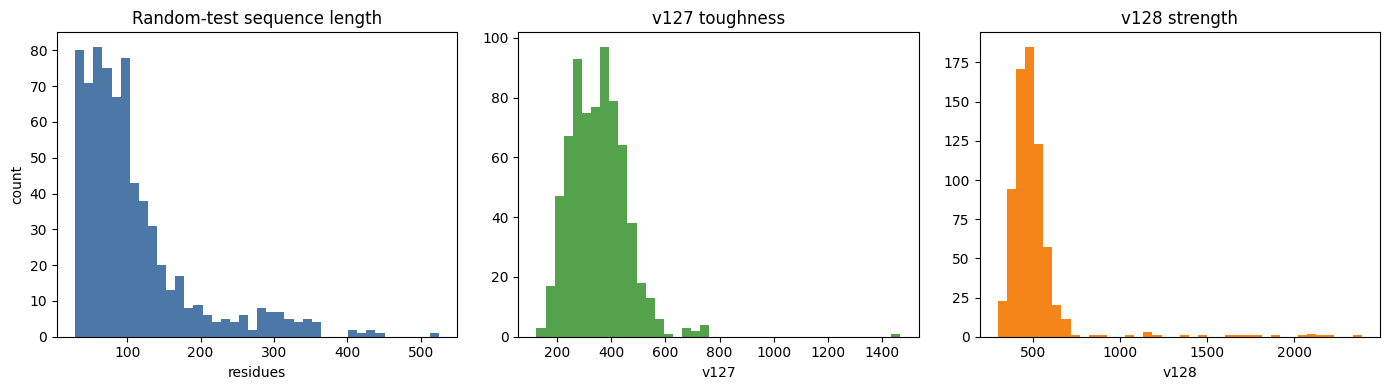

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(test_df['sequence_length'], bins=40, color='#4C78A8')
axes[0].set_title('Random-test sequence length')
axes[0].set_xlabel('residues')
axes[0].set_ylabel('count')
axes[1].hist(test_df['v127'], bins=40, color='#54A24B')
axes[1].set_title('v127 toughness')
axes[1].set_xlabel('v127')
axes[2].hist(test_df['v128'], bins=40, color='#F58518')
axes[2].set_title('v128 strength')
axes[2].set_xlabel('v128')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'cath_test_dataset_overview.png', dpi=200)
plt.show()


## 2. Prepare ColabFold no-MSA Input FASTA

All selected random-test entries are written as individual FASTA files. The output structure directory is:

`output/evaluate-mechanical-predictor/pdb-colab/CATH-test/`


In [6]:
COLABFOLD_INPUT_DIR.mkdir(parents=True, exist_ok=True)
for row in test_df.itertuples(index=False):
    write_fasta(COLABFOLD_INPUT_DIR / f'{row.job_id}.fasta', row.job_id, row.sequence)

colab_input_df = test_df[['PDB_ID', 'job_id', 'sequence_length', 'v127', 'v128', 'sequence', 'groundtruth_pdb_path']].copy()
colab_input_df['colabfold_input_fasta'] = colab_input_df['job_id'].map(lambda x: str(COLABFOLD_INPUT_DIR / f'{x}.fasta'))
colab_input_df.to_csv(CATH_TEST_DIR / 'colabfold_input_sequences.csv', index=False)
print('FASTA files:', len(list(COLABFOLD_INPUT_DIR.glob('*.fasta'))))
display(colab_input_df.head())


FASTA files: 705


,PDB_ID,job_id,sequence_length,v127,v128,sequence,groundtruth_pdb_path,colabfold_input_fasta
0,2w1nA02,2w1nA02,81.0,320.23,395.1016,DFKASEINKKNVTVTWTEPETTEGLEGYILYKDGKKVAEIGKDETS...,/home/jianquanzhao/data/tsinghua/mpprd/pdbs/pd...,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...
24,1wlnA00,1wlnA00,117.0,297.46,548.9145,GSSGSSGPEKLPYLVELSPDGSDSRDKPKLYRLQLSVTEVGTEKFD...,/home/jianquanzhao/data/tsinghua/mpprd/pdbs/pd...,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...
26,2eqmA01,2eqmA01,51.0,322.23,391.2713,GARLEALDYLQKWYPSRIEKIDYEEGKMLVFERWSRYDEWIYWDSN...,/home/jianquanzhao/data/tsinghua/mpprd/pdbs/pd...,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...
53,1g6gB00,1g6gB00,122.0,437.39,513.8506,IVCRVICTTGQIPIRDLSADISQVLKEKRSIKKVWTFGRNPACDYL...,/home/jianquanzhao/data/tsinghua/mpprd/pdbs/pd...,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...
54,2lvcA01,2lvcA01,82.0,320.46,515.2848,IVDPREVFVAITSECVMLACEVDREDAPVRWYKDGQEVEESDFVVL...,/home/jianquanzhao/data/tsinghua/mpprd/pdbs/pd...,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...


## 3. GPU-Gated ColabFold Prediction

This project should not predict the full random-test split on CPU. The following cells launch ColabFold directly and monitor the runtime log. If ColabFold/JAX reports that no GPU is detected, the process is terminated immediately.


In [9]:
def build_colabfold_env() -> dict:
    env = dict(os.environ)
    # cuda_lib = CUDA_HOME / 'targets/x86_64-linux/lib'
    env['CUDA_PATH'] = str(CUDA_HOME)
    env['PATH'] = f"{CUDA_HOME / 'bin'}:{env.get('PATH', '')}"
    # env['LD_LIBRARY_PATH'] = f"{cuda_lib}:{env.get('LD_LIBRARY_PATH', '')}"
    env['XLA_FLAGS'] = f"--xla_gpu_cuda_data_dir={CUDA_HOME} {env.get('XLA_FLAGS', '')}".strip()
    env['MPLCONFIGDIR'] = '/tmp/mprl-matplotlib-cache'
    env['XDG_CACHE_HOME'] = '/tmp/mprl-xdg-cache'
    env['PYTHONUNBUFFERED'] = '1'
    return env


colabfold_env = build_colabfold_env()
NO_GPU_RUNTIME_PATTERNS = (
    'no gpu detected',
    "unable to initialize backend 'cuda'",
    'unable to initialize backend cuda',
    'failed to initialize cuda',
    'cuda_error_no_device',
    'could not find cuda',
)
print('ColabFold runtime environment is configured. GPU availability will be detected from the running ColabFold log.')


ColabFold runtime environment is configured. GPU availability will be detected from the running ColabFold log.


In [10]:
cmd = [
    str(COLABFOLD_BIN),
    '--data', str(COLABFOLD_DATA_DIR),
    '--msa-mode', 'single_sequence',
    '--model-type', 'alphafold2_ptm',
    '--num-models', '1',
    '--num-recycle', '1',
    '--amber',
    '--num-relax', '1',
    '--use-pallas', 'false',
    '--compile-mode', 'fast',
]
if OVERWRITE_EXISTING_RESULTS:
    cmd.append('--overwrite-existing-results')
cmd.extend([str(COLABFOLD_INPUT_DIR), str(COLABFOLD_RESULT_DIR)])

print('ColabFold command:')
print(' '.join(cmd))

def run_colabfold_with_runtime_gpu_detection(command: list[str], env: dict) -> int:
    log_lines = []
    log_path = CATH_TEST_DIR / 'colabfold_runtime.log'
    status_path = CATH_TEST_DIR / 'colabfold_runtime_status.json'
    process = subprocess.Popen(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=env,
    )
    no_gpu_line = None
    timeout_reason = None
    start_time = time.monotonic()
    try:
        assert process.stdout is not None
        while True:
            ready, _, _ = select.select([process.stdout], [], [], 1.0)
            if not ready:
                if process.poll() is not None:
                    break
                if not log_lines and STARTUP_LOG_TIMEOUT_SECONDS is not None:
                    if time.monotonic() - start_time > STARTUP_LOG_TIMEOUT_SECONDS:
                        timeout_reason = f'No ColabFold runtime log appeared within {STARTUP_LOG_TIMEOUT_SECONDS} seconds.'
                        process.terminate()
                        try:
                            process.wait(timeout=20)
                        except subprocess.TimeoutExpired:
                            process.kill()
                            process.wait(timeout=20)
                        break
                continue
            line = process.stdout.readline()
            if line == '' and process.poll() is not None:
                break
            print(line, end='')
            log_lines.append(line)
            lower = line.lower()
            if REQUIRE_GPU_FOR_COLABFOLD and any(pattern in lower for pattern in NO_GPU_RUNTIME_PATTERNS):
                no_gpu_line = line.strip()
                process.terminate()
                try:
                    process.wait(timeout=20)
                except subprocess.TimeoutExpired:
                    process.kill()
                    process.wait(timeout=20)
                break
        return_code = process.wait()
    finally:
        log_path.write_text(''.join(log_lines), encoding='utf-8')

    status = {
        'return_code': int(return_code),
        'terminated_due_to_no_gpu': no_gpu_line is not None,
        'terminated_due_to_log_timeout': timeout_reason is not None,
        'no_gpu_line': no_gpu_line,
        'timeout_reason': timeout_reason,
        'command': command,
        'log_path': str(log_path),
    }
    status_path.write_text(json.dumps(status, indent=2), encoding='utf-8')
    if no_gpu_line is not None:
        raise RuntimeError(
            'ColabFold reported no usable GPU during runtime; prediction was terminated. '
            f'Detected line: {no_gpu_line}'
        )
    if timeout_reason is not None:
        raise RuntimeError(f'ColabFold runtime log timeout; prediction was terminated. {timeout_reason}')
    if return_code != 0:
        raise RuntimeError(f'ColabFold prediction failed with return code {return_code}; see {log_path}.')
    return int(return_code)

if RUN_COLABFOLD:
    return_code = run_colabfold_with_runtime_gpu_detection(cmd, colabfold_env)
    print('ColabFold return code:', return_code)
else:
    print('RUN_COLABFOLD=False; prediction was not launched.')


ColabFold command:
/mnt/data1/home/jianquanzhao/anaconda24/envs/colabfold/bin/colabfold_batch --data /mnt/nas/jianquanzhao/gits/Mechanical-protein-RL/output/evaluate-mechanical-predictor/colabfold-local-data --msa-mode single_sequence --model-type alphafold2_ptm --num-models 1 --num-recycle 1 --amber --num-relax 1 --use-pallas false --compile-mode fast /mnt/nas/jianquanzhao/gits/Mechanical-protein-RL/output/evaluate-mechanical-predictor/pdb-colab/CATH-test/input-fasta /mnt/nas/jianquanzhao/gits/Mechanical-protein-RL/output/evaluate-mechanical-predictor/pdb-colab/CATH-test/results
2026-07-16 14:36:48,094 Running colabfold 1.6.2
2026-07-16 14:36:49,983 Running on GPU
2026-07-16 14:36:50,093 Found 3 citations for tools or databases
2026-07-16 14:36:50,094 Skipping 4nk6A00_11 (already done)
2026-07-16 14:36:50,094 Skipping 3askA01_2 (already done)
2026-07-16 14:36:50,095 Skipping 3tc5A01 (already done)
2026-07-16 14:36:50,095 Skipping 2f1cX00_2 (already done)
2026-07-16 14:36:50,098 Skippi

## 4. Evaluate Ground-Truth and Predicted Structures

Ground-truth evaluation uses the same random-forest artifact and hbond feature extractor as terminal reward. Predicted-structure evaluation uses Amber-relaxed ColabFold PDB files when present.


In [11]:
from model.reward_module.terminal_reward import HbondTopologyTerminalRewardCalculator, TerminalRewardScalarization
from model.reward_module.terminal_reward.model_artifact import SELECTED_HBOND_FEATURES, predict_physical_units

calculator = HbondTopologyTerminalRewardCalculator(
    artifact_path=MODEL_ARTIFACT_PATH,
    scalarization=TerminalRewardScalarization(strength_weight=1.0, toughness_weight=1.0),
)
artifact = calculator.artifact
print('artifact train/val/test:', artifact.train_size, artifact.val_size, artifact.test_size)
print('selected features:', artifact.selected_features)


/mnt/data1/home/jianquanzhao/anaconda24/envs/mprl-vgpt/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/mnt/data1/home/jianquanzhao/anaconda24/envs/mprl-vgpt/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


artifact train/val/test: 5632 704 705
selected features: ('sequence_length', 'hbond_per_residue', 'seq_class_nonlocal_per_residue', 'strong_nonlocal_fraction', 'strong_nonlocal_per_residue', 'nonlocal_backbone_backbone_per_residue', 'hbond_contact_order')


/mnt/data1/home/jianquanzhao/anaconda24/envs/mprl-vgpt/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MultiOutputRegressor from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [12]:
def best_predicted_pdb(job_id: str) -> Optional[Path]:
    patterns = [
        f'{job_id}_relaxed_rank_001*.pdb',
        f'{job_id}*relaxed_rank_001*.pdb',
        f'{job_id}_unrelaxed_rank_001*.pdb',
        f'{job_id}*rank_001*.pdb',
        f'{job_id}*.pdb',
    ]
    candidates = []
    for pattern in patterns:
        candidates.extend(COLABFOLD_RESULT_DIR.glob(pattern))
    candidates = sorted(set(candidates))
    return candidates[0] if candidates else None


def evaluate_pdb_rows(frame: pd.DataFrame, path_column: str, source_label: str) -> pd.DataFrame:
    rows = []
    for row in frame.itertuples(index=False):
        pdb_path = getattr(row, path_column)
        base = {
            'PDB_ID': row.PDB_ID,
            'job_id': row.job_id,
            'source': source_label,
            'sequence_length_label': float(row.sequence_length),
            'v127': float(row.v127),
            'v128': float(row.v128),
            'pdb_path': pdb_path,
        }
        if not pdb_path or not Path(pdb_path).exists():
            rows.append({**base, 'ok': False, 'error': 'missing pdb'})
            continue
        try:
            result = calculator.evaluate_pdb(pdb_path)
            record = {
                **base,
                'ok': True,
                'predicted_v127': result.toughness,
                'predicted_v128': result.strength,
                'terminal_reward': result.reward,
                'mean_plddt': result.feature_diagnostics.get('mean_plddt'),
                'hbond_count': result.feature_diagnostics.get('hbond_count'),
                'hydrogen_atom_count': result.feature_diagnostics.get('hydrogen_atom_count'),
                'feature_warnings': ';'.join(result.feature_diagnostics.get('warnings', ())),
            }
            for key, value in result.features.items():
                record[f'feature_{key}'] = value
            rows.append(record)
        except Exception as exc:
            rows.append({**base, 'ok': False, 'error': repr(exc)})
    return pd.DataFrame(rows)

# Ground-truth structure prediction using precomputed hbond table features.
# This is faster and exactly matches the training feature table.
x_gt_table = test_df.loc[:, list(artifact.selected_features)].to_numpy(dtype=float)
y_gt_pred = predict_physical_units(artifact, x_gt_table)
groundtruth_table_pred = test_df[['PDB_ID', 'job_id', 'sequence_length', 'v127', 'v128', 'groundtruth_pdb_path']].copy()
groundtruth_table_pred['source'] = 'groundtruth_precomputed_features'
groundtruth_table_pred['predicted_v127'] = y_gt_pred[:, 0]
groundtruth_table_pred['predicted_v128'] = y_gt_pred[:, 1]
for feature in artifact.selected_features:
    groundtruth_table_pred[f'feature_{feature}'] = test_df[feature].to_numpy(dtype=float)

test_df['predicted_pdb_path'] = test_df['job_id'].map(lambda x: str(best_predicted_pdb(x) or ''))
predicted_eval = evaluate_pdb_rows(test_df, 'predicted_pdb_path', 'colabfold_predicted_structure')

# Optional direct extraction on ground-truth PDB files. This can expose differences between
# the precomputed training feature table and the current parser/runtime.
groundtruth_direct_eval = evaluate_pdb_rows(test_df, 'groundtruth_pdb_path', 'groundtruth_direct_pdb')

groundtruth_table_pred.to_csv(TABLE_DIR / 'cath_test_groundtruth_precomputed_predictions.csv', index=False)
predicted_eval.to_csv(TABLE_DIR / 'cath_test_colabfold_predicted_structure_predictions.csv', index=False)
groundtruth_direct_eval.to_csv(TABLE_DIR / 'cath_test_groundtruth_direct_pdb_predictions.csv', index=False)

print('precomputed groundtruth rows:', groundtruth_table_pred.shape)
print('predicted structure rows:', predicted_eval.shape, 'ok:', int(predicted_eval.get('ok', pd.Series(dtype=bool)).fillna(False).sum()) if len(predicted_eval) else 0)
print('direct groundtruth rows:', groundtruth_direct_eval.shape, 'ok:', int(groundtruth_direct_eval.get('ok', pd.Series(dtype=bool)).fillna(False).sum()) if len(groundtruth_direct_eval) else 0)
display(predicted_eval.head())


precomputed groundtruth rows: (705, 16)
predicted structure rows: (705, 22) ok: 705
direct groundtruth rows: (705, 22) ok: 705


,PDB_ID,job_id,source,sequence_length_label,v127,v128,pdb_path,ok,predicted_v127,predicted_v128,...,hbond_count,hydrogen_atom_count,feature_warnings,feature_sequence_length,feature_hbond_per_residue,feature_seq_class_nonlocal_per_residue,feature_strong_nonlocal_fraction,feature_strong_nonlocal_per_residue,feature_nonlocal_backbone_backbone_per_residue,feature_hbond_contact_order
0,2w1nA02,2w1nA02,colabfold_predicted_structure,81.0,320.23,395.1016,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...,True,336.423693,458.059664,...,59,655,,81.0,0.728395,0.506173,0.338983,0.246914,0.407407,0.210504
1,1wlnA00,1wlnA00,colabfold_predicted_structure,117.0,297.46,548.9145,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...,True,346.142789,517.943534,...,65,855,,117.0,0.555556,0.316239,0.323077,0.179487,0.188034,0.138330
2,2eqmA01,2eqmA01,colabfold_predicted_structure,51.0,322.23,391.2713,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...,True,248.849148,408.809667,...,33,441,,51.0,0.647059,0.176471,0.121212,0.078431,0.156863,0.112894
3,1g6gB00,1g6gB00,colabfold_predicted_structure,122.0,437.39,513.8506,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...,True,303.638553,666.271477,...,57,980,,122.0,0.467213,0.122951,0.105263,0.049180,0.057377,0.045585
4,2lvcA01,2lvcA01,colabfold_predicted_structure,82.0,320.46,515.2848,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...,True,271.142736,479.091365,...,28,603,,82.0,0.341463,0.158537,0.357143,0.121951,0.134146,0.149390


## 5. Metrics and Comparison


In [13]:
def safe_corr(x, y):
    frame = pd.DataFrame({'x': x, 'y': y}).replace([np.inf, -np.inf], np.nan).dropna()
    if len(frame) < 3 or frame['x'].nunique() < 2 or frame['y'].nunique() < 2:
        return {'n': int(len(frame)), 'pearson': np.nan, 'pearson_p': np.nan, 'spearman': np.nan, 'spearman_p': np.nan}
    pear = pearsonr(frame['x'], frame['y'])
    spear = spearmanr(frame['x'], frame['y'])
    return {'n': int(len(frame)), 'pearson': float(pear.statistic), 'pearson_p': float(pear.pvalue), 'spearman': float(spear.statistic), 'spearman_p': float(spear.pvalue)}


def metric_rows(frame: pd.DataFrame, label: str) -> list[dict]:
    rows = []
    eval_frame = frame.copy()
    if 'ok' in eval_frame.columns:
        eval_frame = eval_frame[eval_frame['ok'].fillna(False)].copy()
    for target_col, pred_col, target_name in [('v127', 'predicted_v127', 'toughness_v127'), ('v128', 'predicted_v128', 'strength_v128')]:
        sub = eval_frame[[target_col, pred_col]].replace([np.inf, -np.inf], np.nan).dropna()
        stats = safe_corr(sub[target_col], sub[pred_col])
        if len(sub) >= 2:
            rmse = math.sqrt(mean_squared_error(sub[target_col], sub[pred_col]))
            mae = mean_absolute_error(sub[target_col], sub[pred_col])
        else:
            rmse = np.nan
            mae = np.nan
        r2 = r2_score(sub[target_col], sub[pred_col]) if len(sub) >= 2 else np.nan
        rows.append({
            'source': label,
            'target': target_name,
            'n': int(len(sub)),
            'r2': float(r2) if np.isfinite(r2) else np.nan,
            'mae': float(mae) if np.isfinite(mae) else np.nan,
            'rmse': float(rmse) if np.isfinite(rmse) else np.nan,
            **stats,
        })
    return rows

metrics = []
metrics.extend(metric_rows(groundtruth_table_pred, 'groundtruth_precomputed_features'))
metrics.extend(metric_rows(groundtruth_direct_eval, 'groundtruth_direct_pdb'))
metrics.extend(metric_rows(predicted_eval, 'colabfold_predicted_structure'))
metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv(TABLE_DIR / 'cath_test_groundtruth_vs_predicted_metrics.csv', index=False)
display(metrics_df)


,source,target,n,r2,mae,rmse,pearson,pearson_p,spearman,spearman_p
0,groundtruth_precomputed_features,toughness_v127,705,0.657354,38.638565,63.391846,0.811334,4.583826e-166,0.889076,9.068739e-241
1,groundtruth_precomputed_features,strength_v128,705,0.306388,65.211485,180.179298,0.565880,6.334079e-61,0.832576,1.570404e-182
2,groundtruth_direct_pdb,toughness_v127,705,0.651426,39.361350,63.937862,0.807287,3.647374e-163,0.887536,8.676202e-239
3,groundtruth_direct_pdb,strength_v128,705,0.291873,66.488795,182.054830,0.546650,3.523649e-56,0.828845,1.784535e-179
4,colabfold_predicted_structure,toughness_v127,705,0.018757,77.227835,107.275121,0.654683,1.672169e-87,0.742674,1.512110e-124
5,colabfold_predicted_structure,strength_v128,705,0.051416,113.974503,210.709731,0.442691,3.402720e-35,0.816757,4.600277e-170


In [14]:
paired = predicted_eval[predicted_eval.get('ok', False).fillna(False)].merge(
    groundtruth_table_pred[['PDB_ID', 'predicted_v127', 'predicted_v128']],
    on='PDB_ID',
    how='inner',
    suffixes=('_predicted_structure', '_groundtruth_features'),
)
if len(paired):
    paired['delta_predicted_v127_minus_groundtruth'] = paired['predicted_v127_predicted_structure'] - paired['predicted_v127_groundtruth_features']
    paired['delta_predicted_v128_minus_groundtruth'] = paired['predicted_v128_predicted_structure'] - paired['predicted_v128_groundtruth_features']
paired.to_csv(TABLE_DIR / 'cath_test_predicted_vs_groundtruth_paired.csv', index=False)
print('paired rows:', len(paired))
display(paired.head())


paired rows: 705


,PDB_ID,job_id,source,sequence_length_label,v127,v128,pdb_path,ok,predicted_v127_predicted_structure,predicted_v128_predicted_structure,...,feature_hbond_per_residue,feature_seq_class_nonlocal_per_residue,feature_strong_nonlocal_fraction,feature_strong_nonlocal_per_residue,feature_nonlocal_backbone_backbone_per_residue,feature_hbond_contact_order,predicted_v127_groundtruth_features,predicted_v128_groundtruth_features,delta_predicted_v127_minus_groundtruth,delta_predicted_v128_minus_groundtruth
0,2w1nA02,2w1nA02,colabfold_predicted_structure,81.0,320.23,395.1016,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...,True,336.423693,458.059664,...,0.728395,0.506173,0.338983,0.246914,0.407407,0.210504,366.935786,477.471672,-30.512092,-19.412008
1,1wlnA00,1wlnA00,colabfold_predicted_structure,117.0,297.46,548.9145,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...,True,346.142789,517.943534,...,0.555556,0.316239,0.323077,0.179487,0.188034,0.138330,299.925553,518.323936,46.217237,-0.380401
2,2eqmA01,2eqmA01,colabfold_predicted_structure,51.0,322.23,391.2713,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...,True,248.849148,408.809667,...,0.647059,0.176471,0.121212,0.078431,0.156863,0.112894,252.941962,407.974619,-4.092814,0.835049
3,1g6gB00,1g6gB00,colabfold_predicted_structure,122.0,437.39,513.8506,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...,True,303.638553,666.271477,...,0.467213,0.122951,0.105263,0.049180,0.057377,0.045585,446.174436,535.892540,-142.535883,130.378936
4,2lvcA01,2lvcA01,colabfold_predicted_structure,82.0,320.46,515.2848,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...,True,271.142736,479.091365,...,0.341463,0.158537,0.357143,0.121951,0.134146,0.149390,303.917452,462.117000,-32.774716,16.974365


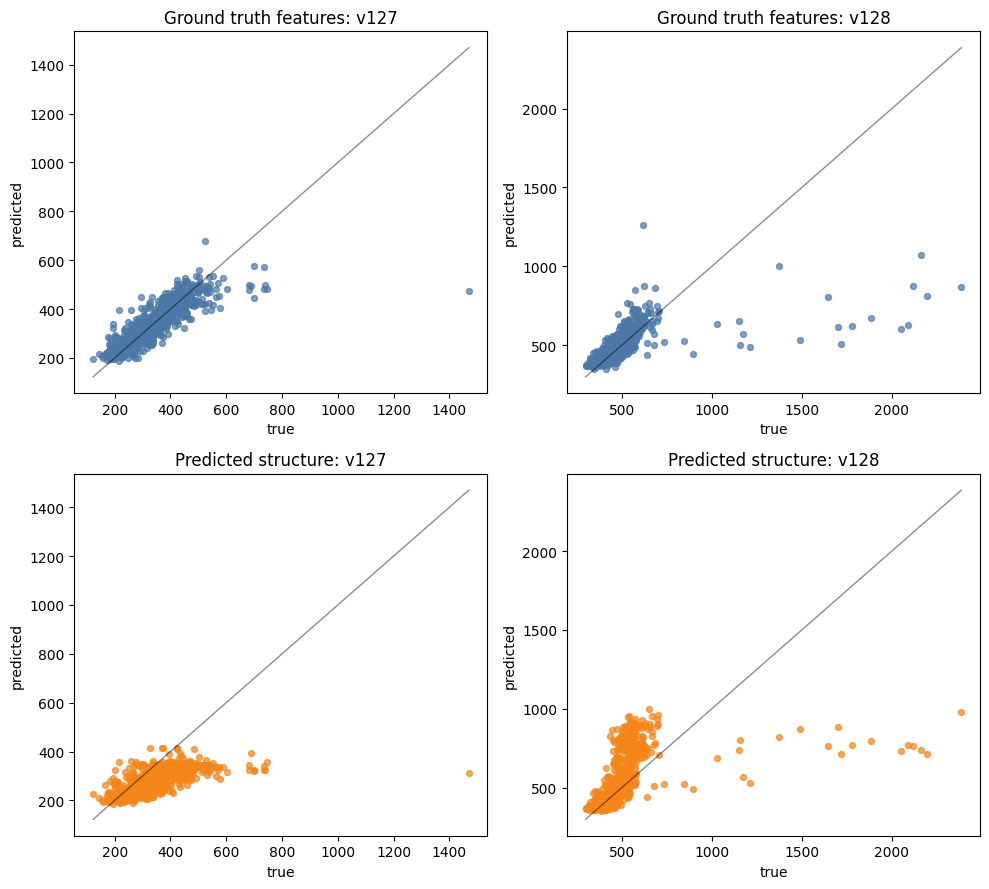

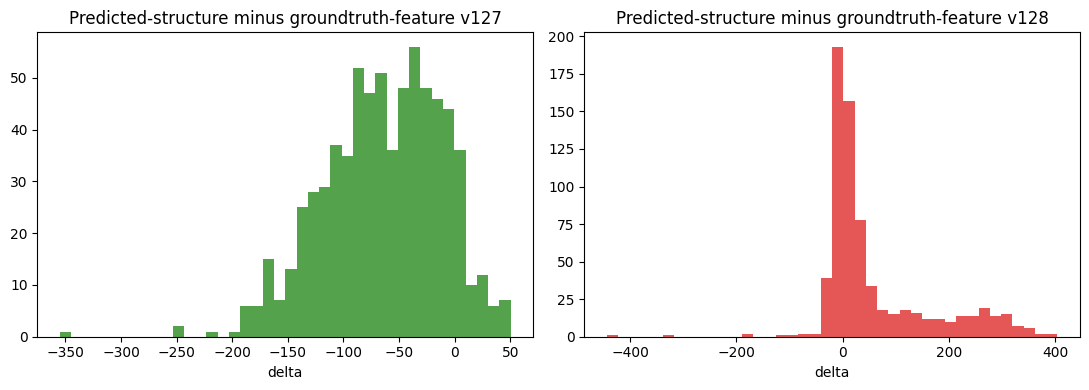

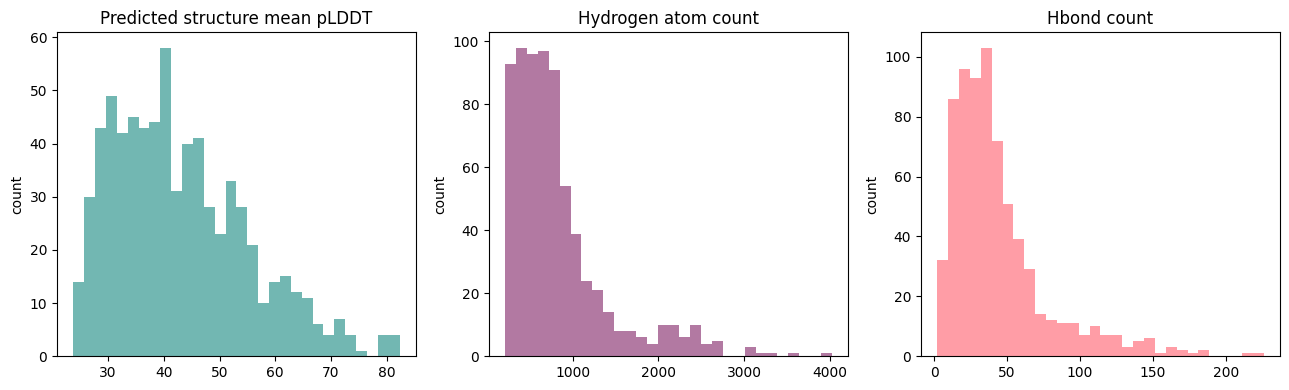

In [15]:
def scatter_panel(ax, frame, x_col, y_col, title, color):
    sub = frame[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    ax.scatter(sub[x_col], sub[y_col], s=18, alpha=0.7, color=color)
    if len(sub):
        low = min(sub[x_col].min(), sub[y_col].min())
        high = max(sub[x_col].max(), sub[y_col].max())
        ax.plot([low, high], [low, high], color='black', linewidth=1, alpha=0.45)
    ax.set_title(title)
    ax.set_xlabel('true')
    ax.set_ylabel('predicted')

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
scatter_panel(axes[0, 0], groundtruth_table_pred, 'v127', 'predicted_v127', 'Ground truth features: v127', '#4C78A8')
scatter_panel(axes[0, 1], groundtruth_table_pred, 'v128', 'predicted_v128', 'Ground truth features: v128', '#4C78A8')
valid_pred = predicted_eval[predicted_eval.get('ok', False).fillna(False)].copy() if len(predicted_eval) else predicted_eval
scatter_panel(axes[1, 0], valid_pred, 'v127', 'predicted_v127', 'Predicted structure: v127', '#F58518')
scatter_panel(axes[1, 1], valid_pred, 'v128', 'predicted_v128', 'Predicted structure: v128', '#F58518')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'cath_test_groundtruth_vs_predicted_scatter.png', dpi=200)
plt.show()

if len(paired):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(paired['delta_predicted_v127_minus_groundtruth'].dropna(), bins=40, color='#54A24B')
    axes[0].set_title('Predicted-structure minus groundtruth-feature v127')
    axes[0].set_xlabel('delta')
    axes[1].hist(paired['delta_predicted_v128_minus_groundtruth'].dropna(), bins=40, color='#E45756')
    axes[1].set_title('Predicted-structure minus groundtruth-feature v128')
    axes[1].set_xlabel('delta')
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / 'cath_test_prediction_delta_histograms.png', dpi=200)
    plt.show()

if len(valid_pred):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].hist(valid_pred['mean_plddt'].dropna(), bins=30, color='#72B7B2')
    axes[0].set_title('Predicted structure mean pLDDT')
    axes[1].hist(valid_pred['hydrogen_atom_count'].dropna(), bins=30, color='#B279A2')
    axes[1].set_title('Hydrogen atom count')
    axes[2].hist(valid_pred['hbond_count'].dropna(), bins=30, color='#FF9DA6')
    axes[2].set_title('Hbond count')
    for ax in axes:
        ax.set_ylabel('count')
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / 'cath_test_predicted_structure_quality_features.png', dpi=200)
    plt.show()


## 6. Analysis Summary


In [16]:
analysis_summary = {
    'test_entries': int(len(test_df)),
    'groundtruth_pdb_exists': int(test_df['groundtruth_pdb_exists'].sum()),
    'predicted_pdb_found': int(test_df['predicted_pdb_path'].map(lambda x: bool(x) and Path(x).exists()).sum()),
    'predicted_eval_ok': int(predicted_eval['ok'].fillna(False).sum()) if 'ok' in predicted_eval else 0,
    'metrics': metrics_df.to_dict(orient='records'),
    'outputs': {
        'cath_test_dir': str(CATH_TEST_DIR),
        'figures': str(FIGURE_DIR),
        'tables': str(TABLE_DIR),
    },
}
(CATH_TEST_DIR / 'comparison_summary.json').write_text(json.dumps(analysis_summary, indent=2), encoding='utf-8')
print(json.dumps(analysis_summary, indent=2))


{
  "test_entries": 705,
  "groundtruth_pdb_exists": 705,
  "predicted_pdb_found": 705,
  "predicted_eval_ok": 705,
  "metrics": [
    {
      "source": "groundtruth_precomputed_features",
      "target": "toughness_v127",
      "n": 705,
      "r2": 0.6573540845979227,
      "mae": 38.63856490336992,
      "rmse": 63.391845980950535,
      "pearson": 0.811334499848291,
      "pearson_p": 4.5838259559409084e-166,
      "spearman": 0.889075849443386,
      "spearman_p": 9.068738670818948e-241
    },
    {
      "source": "groundtruth_precomputed_features",
      "target": "strength_v128",
      "n": 705,
      "r2": 0.30638816622498555,
      "mae": 65.21148487668547,
      "rmse": 180.17929773965056,
      "pearson": 0.5658801943728349,
      "pearson_p": 6.334078607649772e-61,
      "spearman": 0.8325757804066829,
      "spearman_p": 1.5704037388897365e-182
    },
    {
      "source": "groundtruth_direct_pdb",
      "target": "toughness_v127",
      "n": 705,
      "r2": 0.6514260049